In [1]:
import numpy as np
from scipy.integrate import odeint
from scipy.optimize import bisect
import matplotlib.pyplot as plt

In [2]:
# Parâmetros do sistema de Chua
alpha = 10
beta = 14.87
gamma = 0
a = -2/7
b = -1/7

# Função g(x) por partes
def g(x):
    if x >= 1:
        return b * x + a - b
    elif x <= -1:
        return b * x - a + b
    else:
        return a * x

# Derivada por partes de g(x)
def g_prime(x):
    if abs(x) < 1:
        return a
    else:
        return b

# Sistema de Chua
def F(s, t):
    x, y, z = s
    dxdt = alpha * (y - x - g(x))
    dydt = x - y + z
    dzdt = -beta * y - gamma * z
    return [dxdt, dydt, dzdt]

# Jacobiana do sistema de Chua
def DF(s):
    x, y, z = s
    dgdx = g_prime(x)
    return np.array([
        [-alpha * (1 + dgdx), alpha, 0],
        [1, -1, 1],
        [0, -beta, -gamma]
    ])

In [3]:
# Jacobiana do acoplamento
def DH(s):
    x, y, z = s
    return np.array([
    [0, 0, 0],
    [0, 0, 1],
    [0, 0, 0]
])

In [4]:
def MSF(r, t_span=(0, 10**3), dt=0.001):
    t = np.arange(t_span[0], t_span[1], dt)
    s0 = [1.0, 1.0, 1.0]  # Condição inicial
    s_t = odeint(F, s0, t) # Solução numérica do sistema não acoplado usando odeint
    
    xi = np.random.rand(3) # Vetor de perturbação inicial aleatório
    xi /= np.linalg.norm(xi) # Normalização
    LE = 0.0 # Acumulador para o expoente de Lyapunov
    
    for i in range(1, len(t)):
        J = DF(s_t[i]) - r * DH(s_t[i]) # Jacobiano variacional
        xi = np.dot(np.eye(3) + dt * J, xi) # Evolução linear da perturbação (Euler)
        xi_norm = np.linalg.norm(xi) # Norma da perturbação
        LE += np.log(xi_norm) # Contribuição ao expoente
        xi /= xi_norm # Renormalização
    
    return LE / (len(t) * dt) # Média temporal

In [5]:
# Intervalo de r = sigma * lambda_k
r_values = np.linspace(0, 10, 3*(10**2))
LE_values = [MSF(r) for r in r_values]

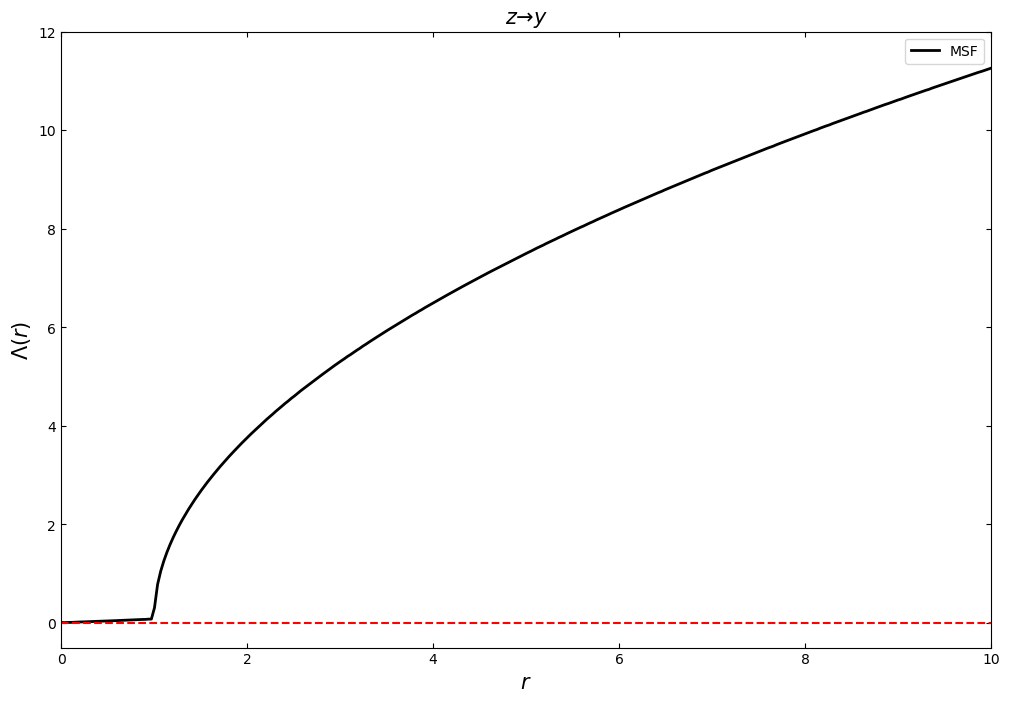

In [16]:
# Plotar MSF
plt.figure(figsize=(12, 8))
plt.plot(r_values, LE_values, 'k', linewidth=2, label='MSF')
plt.axhline(0, color='r', linestyle='--')
plt.xlim(0, 10)
plt.ylim(-0.5, 12)
plt.xlabel(r'$r$', fontsize=15)
plt.ylabel(r'$\Lambda(r)$', fontsize=15)
plt.title(r'$z \to y$', fontsize=15)
plt.legend()
plt.grid(False)
plt.tick_params(which='both', direction='in', top=True, right=True)
plt.show()

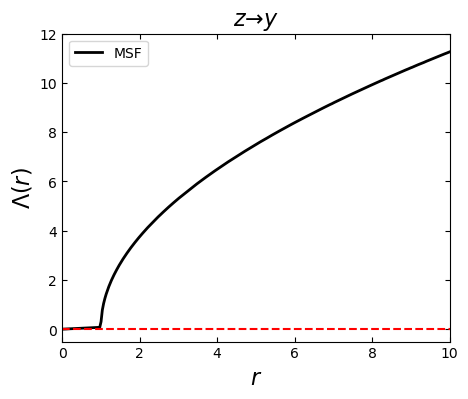

In [17]:
# Plotar MSF
fig13=plt.figure(figsize=(5, 4))
plt.plot(r_values, LE_values, 'k', linewidth=2, label='MSF')
plt.axhline(0, color='r', linestyle='--')
plt.xlim(0, 10)
plt.ylim(-0.5, 12)
plt.xlabel(r'$r$', fontsize=16)
plt.ylabel(r'$\Lambda(r)$', fontsize=16)
plt.title(r'$z \to y$', fontsize=16)
plt.legend()
plt.grid(False)
plt.tick_params(which='both', direction='in', top=True, right=True)
fig13.savefig('zy.pdf', format='pdf', dpi=300)
plt.show()